In [2]:
from google.colab import files
uploaded=files.upload()

Saving udemy_output_All_Finance__Accounting_p1_p626.csv to udemy_output_All_Finance__Accounting_p1_p626.csv


In [3]:
import pandas as pd
df=pd.read_csv(r'udemy_output_All_Finance__Accounting_p1_p626.csv')

In [28]:
print('\n\n',df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13608 entries, 0 to 13607
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            13608 non-null  int64  
 1   title                         13608 non-null  object 
 2   url                           13608 non-null  object 
 3   is_paid                       13608 non-null  bool   
 4   num_subscribers               13608 non-null  int64  
 5   avg_rating                    13608 non-null  float64
 6   avg_rating_recent             13608 non-null  float64
 7   rating                        13608 non-null  float64
 8   num_reviews                   13608 non-null  int64  
 9   is_wishlisted                 13608 non-null  bool   
 10  num_published_lectures        13608 non-null  int64  
 11  num_published_practice_tests  13608 non-null  int64  
 12  created                       13608 non-null  object 
 13  p

In [8]:
print(df['is_paid'].value_counts()) #most of the courses are paid
print('\n\n',(df['avg_rating'].describe()))
print('\n\n',(df['avg_rating_recent'].describe()))
print('\n\n',(df['rating'].describe()))

is_paid
True     13112
False      496
Name: count, dtype: int64


 count    13608.000000
mean         3.923293
std          1.031304
min          0.000000
25%          3.800000
50%          4.194440
75%          4.450000
max          5.000000
Name: avg_rating, dtype: float64


 count    13608.000000
mean         3.912242
std          1.039237
min          0.000000
25%          3.787315
50%          4.181735
75%          4.452105
max          5.000000
Name: avg_rating_recent, dtype: float64


 count    13608.000000
mean         3.912242
std          1.039237
min          0.000000
25%          3.787315
50%          4.181735
75%          4.452105
max          5.000000
Name: rating, dtype: float64


In [ ]:
print(df['discount_price__amount'])
df['discount_price__amount']=df['discount_price__amount'].fillna(df['discount_price__amount'].mode()[0])

df['price_detail__amount']=df['price_detail__amount'].fillna(df['price_detail__amount'].mode()[0])
print('\n\n',df['price_detail__amount'])



0        455.0
1        455.0
2        455.0
3        455.0
4        455.0
         ...  
13603    455.0
13604    455.0
13605    455.0
13606    455.0
13607    455.0
Name: discount_price__amount, Length: 13608, dtype: float64


 0        8640.0
1        8640.0
2        8640.0
3        8640.0
4        8640.0
          ...  
13603    8640.0
13604    8640.0
13605    8640.0
13606    8640.0
13607    8640.0
Name: price_detail__amount, Length: 13608, dtype: float64


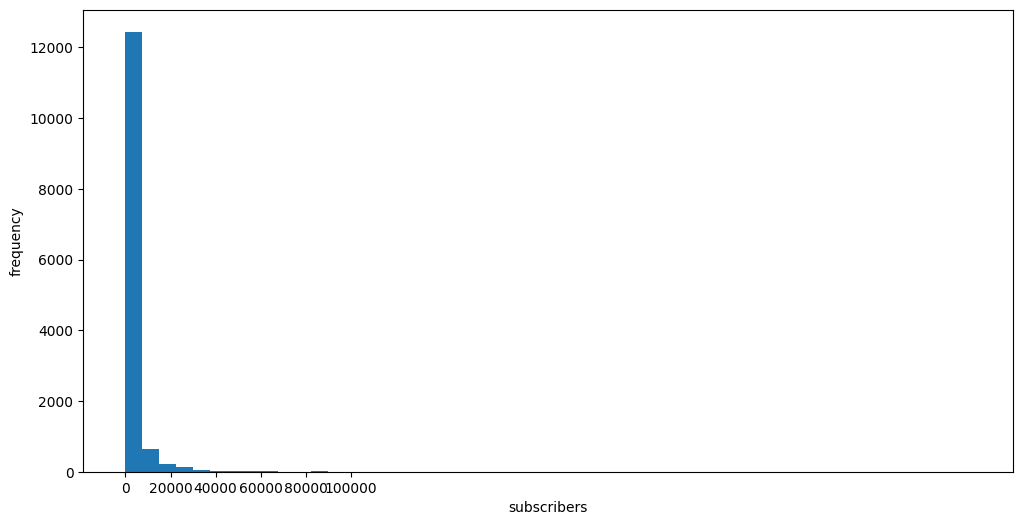

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.hist(df['num_subscribers'],bins=50)
plt.xlabel('subscribers')
plt.ylabel('frequency')
plt.xticks(ticks=[0,20000,40000,60000,80000,100000])
plt.show()

maximum courses have around 10k subscriber..

very few courses beyond 70k and no subscriber beyond 1 lac for any course

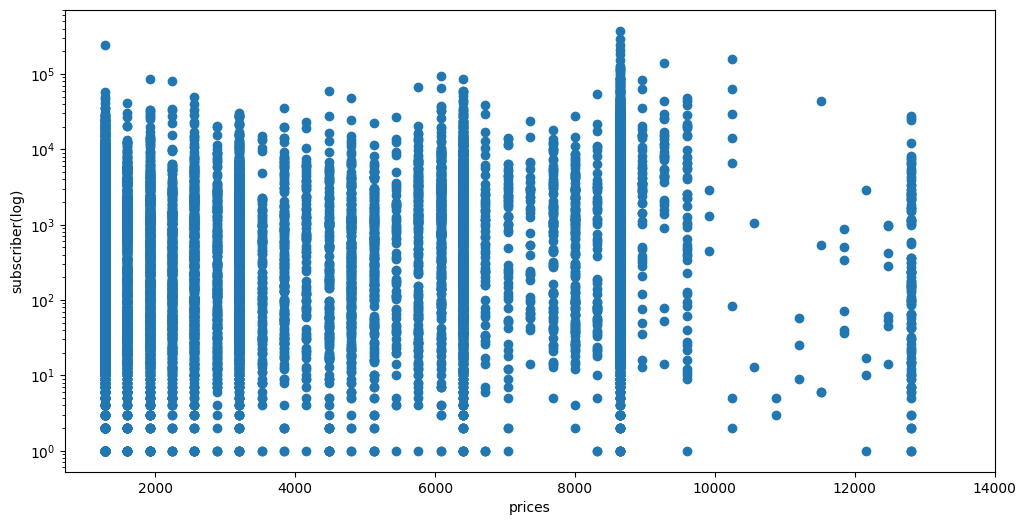

,price_detail__amount,num_subscribers
price_detail__amount,1.000000,0.147523
num_subscribers,0.147523,1.000000


In [5]:
plt.figure(figsize=(12,6))
plt.scatter(df['price_detail__amount'],df['num_subscribers'])

plt.yscale('log')
plt.xlabel('prices')
plt.ylabel('subscriber(log)')
plt.xticks(ticks=[2000,4000,6000,8000,10000,12000,14000])
plt.show()

df[['price_detail__amount','num_subscribers']].corr()

The correlation between course price and subscriber count is 0.148, indicating a weak positive relationship. Course price does not appear to be a major factor influencing enrollments

In [33]:
df.groupby('is_paid')['num_subscribers'].mean()


,num_subscribers
is_paid,
False,5861.286290
True,2732.986577


In [8]:
df.groupby('is_paid')['num_subscribers'].median()

,num_subscribers
is_paid,
False,2583.0
True,495.0


The value of mean when course is not paid vs when is paid comes out to be double.Similarly,in median,value for not paid is 6 times than for paid.The subscribers for not paid courses as expected comes out to be more than doubled on an average.And half of the paid courses have subscribers less than 500...



In [11]:
df[['avg_rating_recent','num_subscribers']].corr()

,avg_rating_recent,num_subscribers
avg_rating_recent,1.000000,0.084198
num_subscribers,0.084198,1.000000


The correlation between avg_rating and subscriber count is 0.084, indicating a weak positive relationship. Avg_rating does not appear to be a major factor influencing enrollments

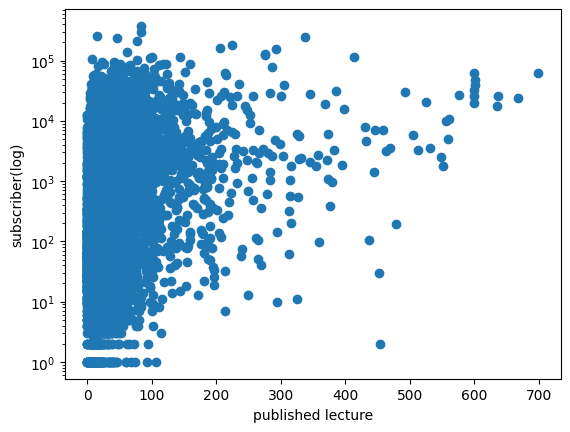

,num_published_lectures,num_subscribers
num_published_lectures,1.000000,0.211672
num_subscribers,0.211672,1.000000


In [35]:
plt.scatter(df['num_published_lectures'],df['num_subscribers'])
plt.yscale('log')
plt.xlabel('published lecture')
plt.ylabel('subscriber(log)')
plt.show()

df[['num_published_lectures','num_subscribers']].corr()


The correlation between published lec and subscriber count is 0.211, indicating a positive relationship. For lower numbers of published lectures that the correlation between published lecture and subscribers doesn't exist.But it can be seen that with increase in number of published lecture tendency is that number of subscriber is increasing stably.

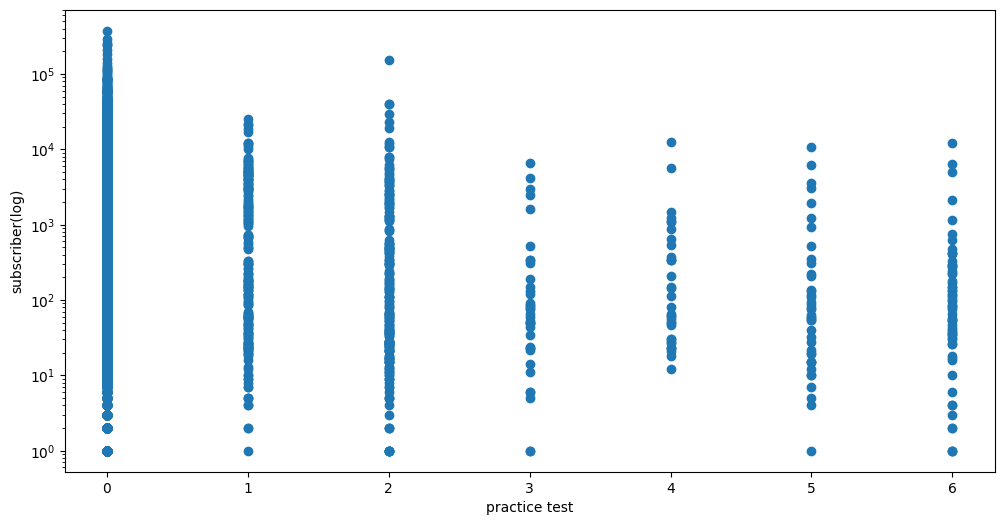

,num_published_practice_tests,num_subscribers
num_published_practice_tests,1.000000,-0.028835
num_subscribers,-0.028835,1.000000


In [37]:
plt.figure(figsize=(12,6))

plt.scatter(df['num_published_practice_tests'],df['num_subscribers'])
plt.yscale('log')
plt.xlabel('practice test')
plt.ylabel('subscriber(log)')
plt.show()

df[['num_published_practice_tests','num_subscribers']].corr()

The correlation between num_published_practice tests and num_subscribers is -0.028.It suggests very weak correlation.Consistency of correlation between higher number of subscriber with more practice tests improves but still not consistent enough

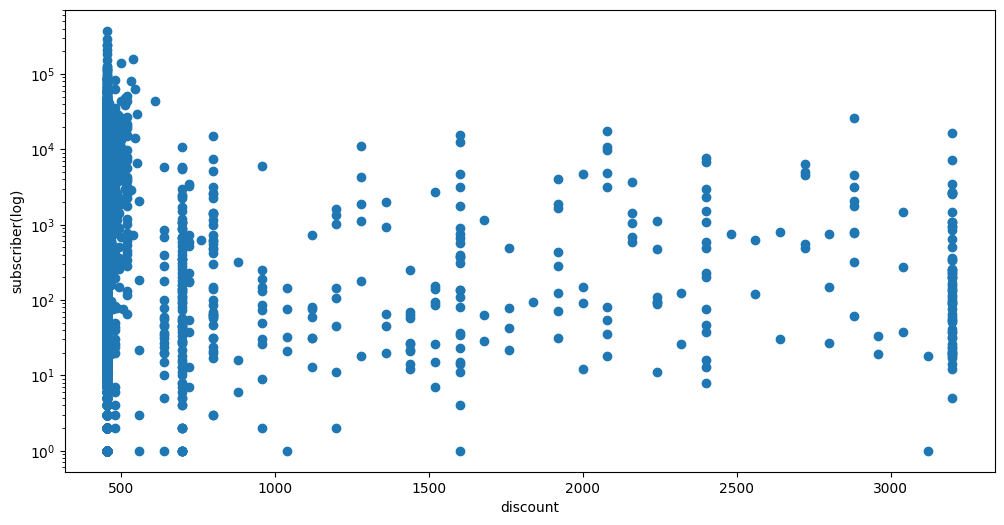

,discount_price__amount,num_subscribers
discount_price__amount,1.000000,-0.022307
num_subscribers,-0.022307,1.000000


In [38]:
plt.figure(figsize=(12,6))
plt.scatter(df['discount_price__amount'],df['num_subscribers'])
plt.yscale('log')
plt.xlabel('discount')
plt.ylabel('subscriber(log)')
plt.show()

df[['discount_price__amount','num_subscribers']].corr()

The correlation between discount and num_subscribers is -0.028.It suggests very weak correlation.Consistency of correlation between higher number of subscriber with more discount improves but still not consistent enough

Paid and unpaid courses impact the number of subscribers to the highest extent.And no. of published lectures also has some impact..

Rest of the factors like ratings,discount,price,practice tests doesn't impact the subscriber number to that extent..

So,students subscribe to courses according to their requirements and other factors doesn't impact them as much...